In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("C:/Users/VOLKAN/Desktop/Coffee Shop Sales.xlsx")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [6]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [10]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


<Axes: xlabel='transaction_date'>

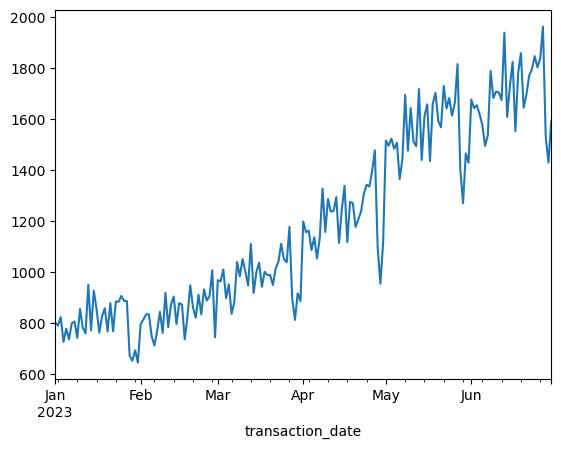

In [28]:
# Günlük toplam satış miktarı
df.groupby("transaction_date")["transaction_qty"].sum().plot()

<Axes: xlabel='hour'>

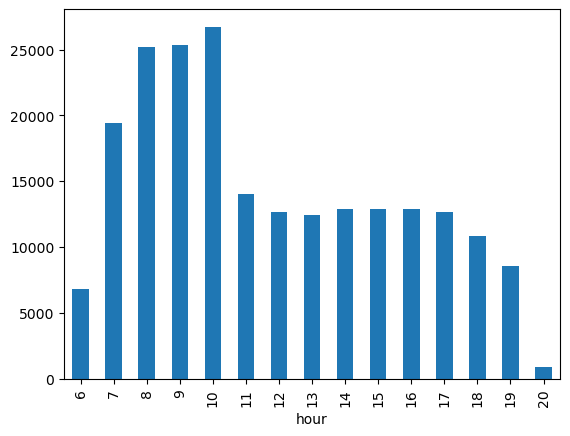

In [30]:
# Saatlik yoğunluk
df["hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M:%S").dt.hour
df.groupby("hour")["transaction_qty"].sum().plot(kind="bar")

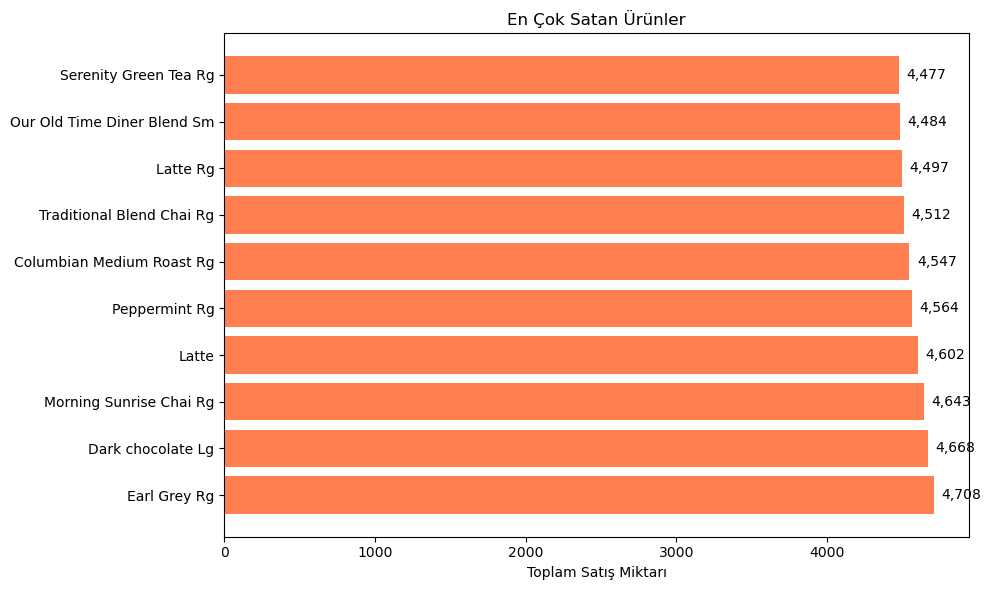

In [62]:
# En çok satan ürünler
top_products = df.groupby("product_detail")["transaction_qty"].sum().sort_values(ascending=False).head(10)

# Grafik çizimi
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_products.index, top_products.values, color="coral")

# Rakamları barların sonuna ekle
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va='center', fontsize=10)

ax.set_xlabel("Toplam Satış Miktarı")
ax.set_title("En Çok Satan Ürünler")
plt.tight_layout()
plt.show()


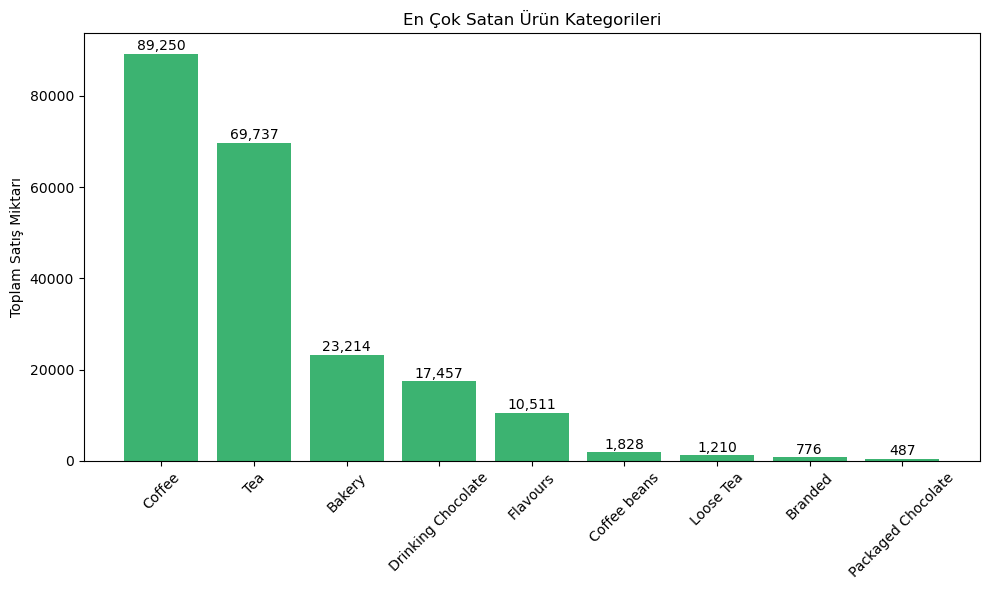

In [64]:
import matplotlib.pyplot as plt

# En çok satan ürün kategorileri
category_sales = df.groupby("product_category")["transaction_qty"].sum().sort_values(ascending=False)

# Grafik çizimi
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(category_sales.index, category_sales.values, color="mediumseagreen")

# Rakamları barların üstüne ekle
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 100,
            f"{int(height):,}", ha='center', va='bottom', fontsize=10)

ax.set_ylabel("Toplam Satış Miktarı")
ax.set_title("En Çok Satan Ürün Kategorileri")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


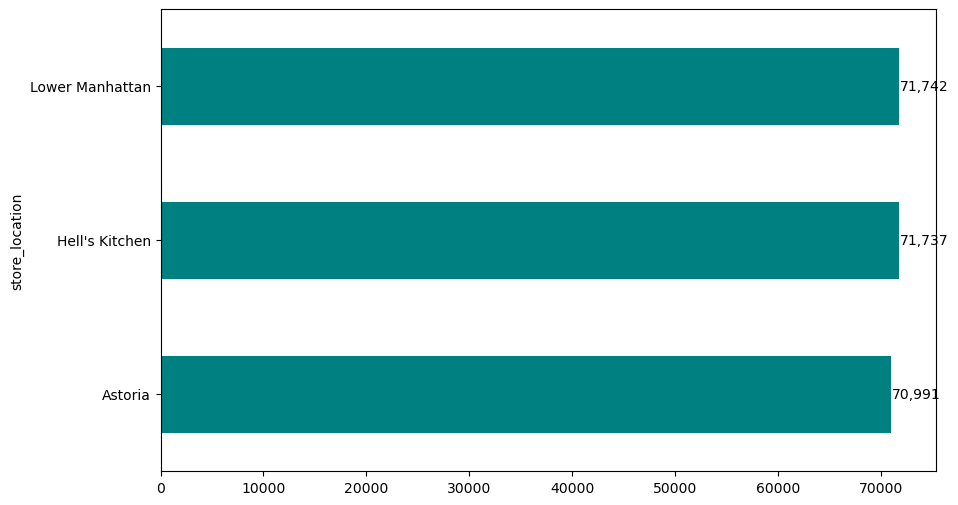

In [58]:
store_sales = df.groupby("store_location")["transaction_qty"].sum().sort_values()
ax = store_sales.plot(kind="barh", figsize=(10,6), color="teal")

# Bar üstüne rakam ekle
for i, v in enumerate(store_sales):
    ax.text(v + 100, i, f"{int(v):,}", va="center")


In [42]:
#☕ Coffee Sales Analysis Project

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# 1. Setup: Klasörler ve Path Ayarları
ROOT = Path(".")
DATA_PATH = ROOT / "data" / "C:/Users/VOLKAN/Desktop/Coffee Shop Sales.xlsx"
OUT_DIR = ROOT / "output"
FIG_DIR = OUT_DIR / "figures"
DATA_OUT = OUT_DIR / "data"

for p in (OUT_DIR, FIG_DIR, DATA_OUT):
    p.mkdir(parents=True, exist_ok=True)

print("Klasör yapısı hazır. Veri path:", DATA_PATH)

Klasör yapısı hazır. Veri path: C:\Users\VOLKAN\Desktop\Coffee Shop Sales.xlsx


In [46]:
# 2. Veri Yükleme ve Temizleme
df = pd.read_excel(DATA_PATH, sheet_name="Transactions", engine="openpyxl")

# Tarih ve saat düzenleme
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_time'] = df['transaction_time'].astype(str).str.strip()
df['time_delta'] = pd.to_timedelta(df['transaction_time'], errors='coerce')

# Tarih + Saat birleşimi
df['transaction_datetime'] = df['transaction_date'] + df['time_delta'].fillna(pd.Timedelta(seconds=0))

# Satış sütunu
df['sales'] = df['transaction_qty'] * df['unit_price']

print("Veri örneği:")
print(df.head())

Veri örneği:
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail      time_delta  \
0  Gourmet brewed coffee

In [47]:
# 3. Veri Kalitesi Raporu
# ------------------------------------------------------
def dq_report(df):
    rep = {}
    rep['rows'] = len(df)
    rep['cols'] = df.shape[1]
    rep['missing_per_col'] = df.isnull().sum().to_dict()
    rep['negative_qty'] = int((df['transaction_qty'] < 0).sum())
    rep['zero_or_negative_price'] = int((df['unit_price'] <= 0).sum())
    rep['duplicate_lines'] = int(df.duplicated().sum())
    rep['unique_transactions'] = int(df['transaction_id'].nunique())
    return rep

dq = dq_report(df)
print("Veri Kalitesi Raporu:", dq)

Veri Kalitesi Raporu: {'rows': 149116, 'cols': 14, 'missing_per_col': {'transaction_id': 0, 'transaction_date': 0, 'transaction_time': 0, 'transaction_qty': 0, 'store_id': 0, 'store_location': 0, 'product_id': 0, 'unit_price': 0, 'product_category': 0, 'product_type': 0, 'product_detail': 0, 'time_delta': 0, 'transaction_datetime': 0, 'sales': 0}, 'negative_qty': 0, 'zero_or_negative_price': 0, 'duplicate_lines': 0, 'unique_transactions': 149116}


In [48]:
# 4. Transaction-level Agregasyon
# ------------------------------------------------------
trx = df.groupby('transaction_id').agg(
    transaction_date=('transaction_date','min'),
    transaction_datetime=('transaction_datetime','min'),
    store_id=('store_id','first'),
    store_location=('store_location','first'),
    total_items=('transaction_qty','sum'),
    total_sales=('sales','sum'),
    n_line_items=('product_id','nunique')
).reset_index()

print("Ortalama sepet büyüklüğü:", round(trx['total_sales'].mean(), 2))

Ortalama sepet büyüklüğü: 4.69


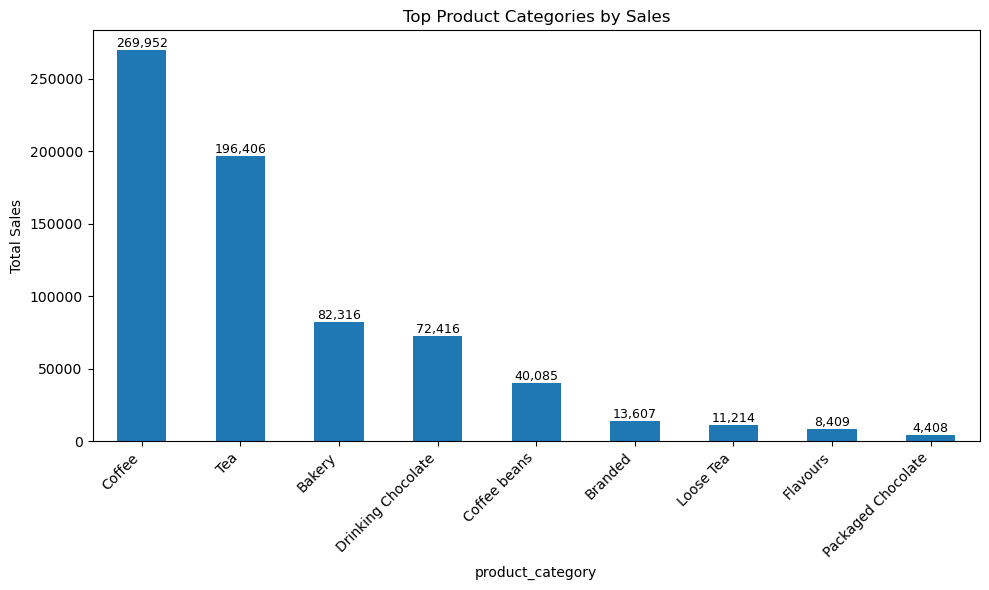

In [49]:
# 5a. Kategori bazlı satış
cat = df.groupby('product_category').agg(total_sales=('sales','sum')).sort_values('total_sales', ascending=False)
ax = cat['total_sales'].plot(kind='bar', figsize=(10,6))
ax.set_ylabel('Total Sales')
ax.set_title('Top Product Categories by Sales')
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x()+p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / "top_categories.png")
plt.show()
plt.close()

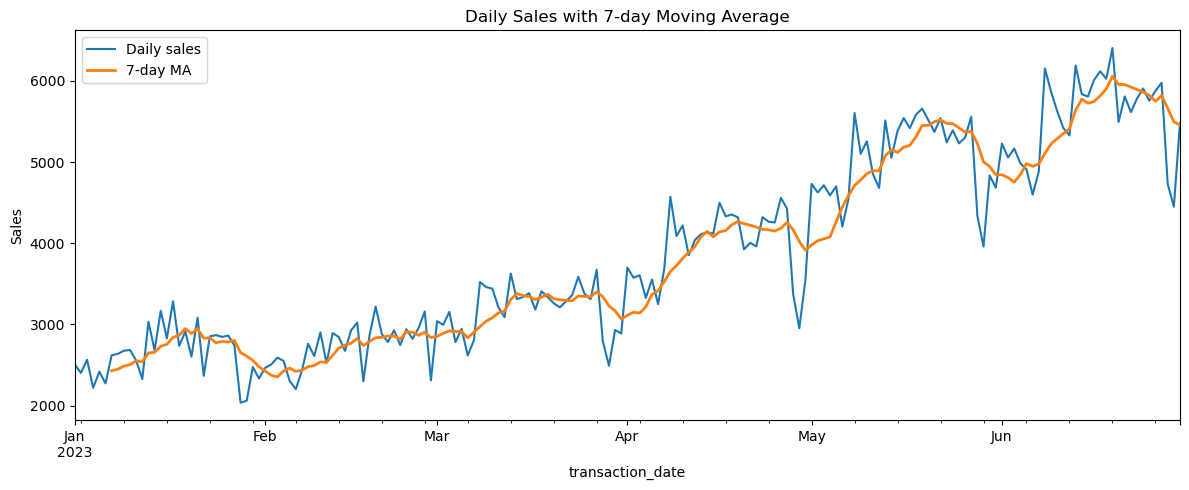

In [50]:
# 5b. Günlük satış + 7 günlük MA
daily = df.groupby('transaction_date')['sales'].sum().sort_index()
plt.figure(figsize=(12,5))
daily.plot(label='Daily sales')
daily.rolling(7).mean().plot(label='7-day MA', linewidth=2)
plt.legend()
plt.ylabel('Sales')
plt.title('Daily Sales with 7-day Moving Average')
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_sales_7dma.png")
plt.show()
plt.close()

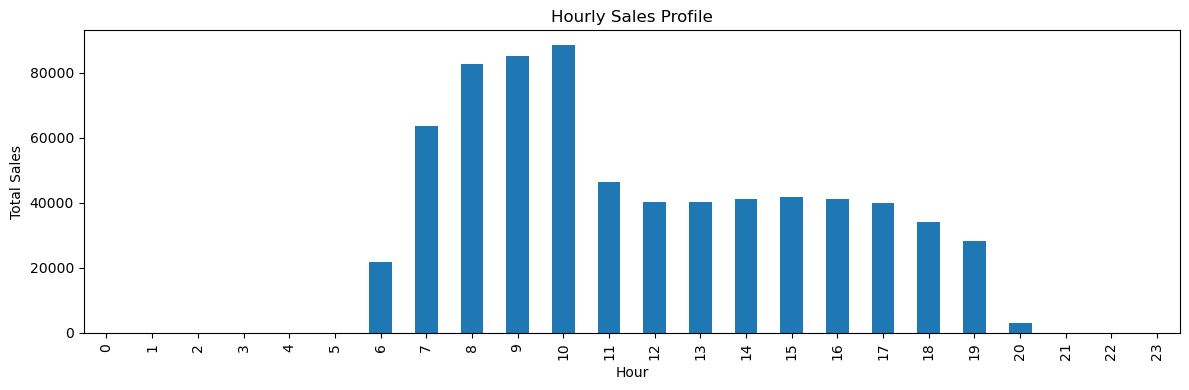

In [51]:
# 5c. Saatlik yoğunluk
trx['hour'] = trx['transaction_datetime'].dt.hour
hourly = trx.groupby('hour')['total_sales'].sum().reindex(range(24), fill_value=0)
hourly.plot(kind='bar', figsize=(12,4))
plt.title('Hourly Sales Profile')
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig(FIG_DIR / "hourly_profile.png")
plt.show()
plt.close()

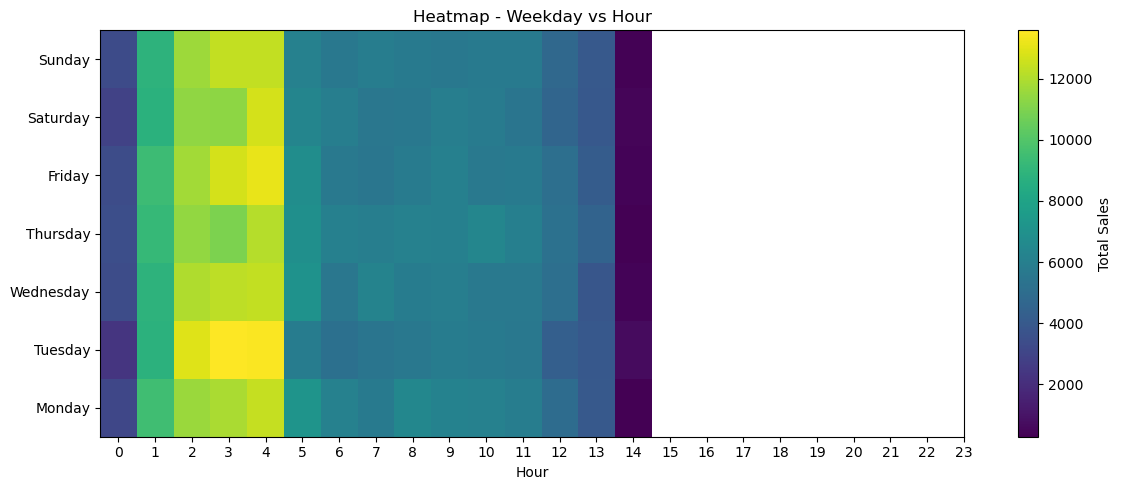

In [52]:
# 5d. Heatmap (weekday vs hour)
trx['weekday'] = trx['transaction_datetime'].dt.day_name()
pivot = trx.pivot_table(index='weekday', columns='hour', values='total_sales', aggfunc='sum').reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).fillna(0)
plt.figure(figsize=(12,5))
plt.imshow(pivot, aspect='auto', origin='lower', interpolation='nearest')
plt.colorbar(label='Total Sales')
plt.xticks(range(24), range(24))
plt.yticks(range(7), pivot.index)
plt.xlabel('Hour')
plt.title('Heatmap - Weekday vs Hour')
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_weekday_hour.png")
plt.show()
plt.close()

In [53]:
# 6. Çıktıları Kaydetme
# ------------------------------------------------------
df.to_csv(DATA_OUT / "transactions_raw.csv", index=False)
trx.to_csv(DATA_OUT / "transactions_agg.csv", index=False)
cat.to_csv(DATA_OUT / "categories_sales.csv")

print("Çıktılar kaydedildi:", DATA_OUT)

Çıktılar kaydedildi: output\data
